In [8]:
import pandas as pd


In [10]:
import os
print(os.getcwd())

C:\Users\oba032\GitHub_Watch\Repository\Watch_repository\data


In [12]:
with open('AW_Export_rafinert.csv', 'r') as file:
    for i in range(50):
        print(file.readline())


ï»¿Date;Active Energy (kJ);Apple Exercise Time (min);z;Apple Stand Time (min);Blood Oxygen Saturation (%);Environmental Audio Exposure (dBASPL);Headphone Audio Exposure (dBASPL);Heart Rate [Min] (bpm);Heart Rate [Max] (bpm);Heart Rate [Avg] (bpm);Heart Rate Variability (ms);Physical Effort (MET);Respiratory Rate (count/min);Resting Energy (kJ);Resting Heart Rate (bpm);Sleep Analysis [Asleep] (hr);Sleep Analysis [Core] (hr);Sleep Analysis [Deep] (hr);Sleep Analysis [REM] (hr);Sleep Analysis [Awake] (hr);Step Count (steps);Walking + Running Distance (km);Walking Heart Rate Average (bpm);Walking Speed (km/hr);Walking Step Length (cm)

24.12.2024 00:00;222,37;;;;97;66,01;48,48;61;72;68,22;56,86;2,48;;6598;;;;;;;1389;0,885;;3,44;56,6

25.12.2024 00:00;1540;9;12;31;97,97;56,13;48,81;52;110;71,82;49,77;3,25;14,48;9168;63;2,583333333;3,225;0,475;0,45;0,016666667;2753;2,08;91,5;3,46;58

26.12.2024 00:00;3384;66;11;77;97,79;56,73;53,73;54;162;87,17;43,35;3,38;15,67;9117;63;0;5,991666667;0,958333

In [14]:
df = pd.read_csv('AW_Export_rafinert.csv', sep=';')
print(df.head())


               Date Active Energy (kJ)  Apple Exercise Time (min)     z  \
0  24.12.2024 00:00             222,37                        NaN   NaN   
1  25.12.2024 00:00               1540                        9.0  12.0   
2  26.12.2024 00:00               3384                       66.0  11.0   
3  27.12.2024 00:00               3786                       75.0  14.0   
4  28.12.2024 00:00               1562                        2.0  10.0   

   Apple Stand Time (min) Blood Oxygen Saturation (%)  \
0                     NaN                          97   
1                    31.0                       97,97   
2                    77.0                       97,79   
3                   146.0                       98,15   
4                    25.0                       97,28   

  Environmental Audio Exposure (dBASPL) Headphone Audio Exposure (dBASPL)  \
0                                 66,01                             48,48   
1                                 56,13             

In [16]:
print(df.columns)
print(df.dtypes)
print(df.describe())


Index(['Date', 'Active Energy (kJ)', 'Apple Exercise Time (min)', 'z',
       'Apple Stand Time (min)', 'Blood Oxygen Saturation (%)',
       'Environmental Audio Exposure (dBASPL)',
       'Headphone Audio Exposure (dBASPL)', 'Heart Rate [Min] (bpm)',
       'Heart Rate [Max] (bpm)', 'Heart Rate [Avg] (bpm)',
       'Heart Rate Variability (ms)', 'Physical Effort (MET)',
       'Respiratory Rate (count/min)', 'Resting Energy (kJ)',
       'Resting Heart Rate (bpm)', 'Sleep Analysis [Asleep] (hr)',
       'Sleep Analysis [Core] (hr)', 'Sleep Analysis [Deep] (hr)',
       'Sleep Analysis [REM] (hr)', 'Sleep Analysis [Awake] (hr)',
       'Step Count (steps)', 'Walking + Running Distance (km)',
       'Walking Heart Rate Average (bpm)', 'Walking Speed (km/hr)',
       'Walking Step Length (cm)'],
      dtype='object')
Date                                      object
Active Energy (kJ)                        object
Apple Exercise Time (min)                float64
z                        

In [18]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

C:\Users\oba032\AppData\Local\Temp\ipykernel_13748\2263964175.py:1: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [20]:
grouped = df.groupby('Date').agg({
    'Active Energy (kJ)': 'sum',
    'Step Count (steps)': 'sum',
    'Apple Stand Time (min)': 'sum',
    'Heart Rate [Min] (bpm)': 'mean',
    'Heart Rate [Max] (bpm)': 'mean',
    'Resting Heart Rate (bpm)': 'mean',
    'Resting Energy (kJ)': 'mean',
    'Sleep Analysis [Asleep] (hr)': 'sum',
    'Sleep Analysis [Core] (hr)': 'sum',
    'Sleep Analysis [Deep] (hr)' : 'sum',
    'Sleep Analysis [REM] (hr)' : 'sum'
}).reset_index()

print(grouped)

         Date Active Energy (kJ)  Step Count (steps)  Apple Stand Time (min)  \
0  2024-12-24             222,37                1389                     0.0   
1  2024-12-25               1540                2753                    31.0   
2  2024-12-26               3384                3290                    77.0   
3  2024-12-27               3786                7745                   146.0   
4  2024-12-28               1562                2004                    25.0   
5  2024-12-29               3995                4299                    94.0   
6  2024-12-30               2035                4320                    69.0   
7  2024-12-31               2803                7956                   121.0   
8  2025-01-01               1404                4207                    60.0   
9  2025-01-02               2306                6436                    99.0   
10 2025-01-03               4499                8865                   172.0   
11 2025-01-04               4731        

In [22]:
list_of_days = grouped.to_dict(orient='records')

print(list_of_days)

[{'Date': Timestamp('2024-12-24 00:00:00'), 'Active Energy (kJ)': '222,37', 'Step Count (steps)': 1389, 'Apple Stand Time (min)': 0.0, 'Heart Rate [Min] (bpm)': 61.0, 'Heart Rate [Max] (bpm)': 72.0, 'Resting Heart Rate (bpm)': nan, 'Resting Energy (kJ)': 6598.0, 'Sleep Analysis [Asleep] (hr)': 0, 'Sleep Analysis [Core] (hr)': 0, 'Sleep Analysis [Deep] (hr)': 0, 'Sleep Analysis [REM] (hr)': 0}, {'Date': Timestamp('2024-12-25 00:00:00'), 'Active Energy (kJ)': '1540', 'Step Count (steps)': 2753, 'Apple Stand Time (min)': 31.0, 'Heart Rate [Min] (bpm)': 52.0, 'Heart Rate [Max] (bpm)': 110.0, 'Resting Heart Rate (bpm)': 63.0, 'Resting Energy (kJ)': 9168.0, 'Sleep Analysis [Asleep] (hr)': '2,583333333', 'Sleep Analysis [Core] (hr)': '3,225', 'Sleep Analysis [Deep] (hr)': '0,475', 'Sleep Analysis [REM] (hr)': '0,45'}, {'Date': Timestamp('2024-12-26 00:00:00'), 'Active Energy (kJ)': '3384', 'Step Count (steps)': 3290, 'Apple Stand Time (min)': 77.0, 'Heart Rate [Min] (bpm)': 54.0, 'Heart Rate 

In [24]:
df['Active Energy (kJ)'] = pd.to_numeric(df['Active Energy (kJ)'], errors='coerce')
df['Resting Energy (kJ)'] = pd.to_numeric(df['Resting Energy (kJ)'], errors='coerce')
print(df[['Active Energy (kJ)', 'Resting Energy (kJ)']].isna().sum())


Active Energy (kJ)     4
Resting Energy (kJ)    0
dtype: int64


In [26]:
kJ_to_kcal = 0.239006

In [28]:
df['Active Energy (kcal)'] = df['Active Energy (kJ)'] * kJ_to_kcal
df['Resting Energy (kcal)'] = df['Resting Energy (kJ)'] * kJ_to_kcal

In [30]:
import pandas as pd

grouped = df.groupby('Date').agg({
    'Active Energy (kcal)': 'sum',
    'Step Count (steps)': 'sum',
    'Apple Stand Time (min)': 'sum',
    'Heart Rate [Min] (bpm)': 'mean',
    'Heart Rate [Max] (bpm)': 'mean',
    'Resting Heart Rate (bpm)': 'mean',
    'Resting Energy (kcal)': 'mean'
}).reset_index()

print(grouped)

         Date  Active Energy (kcal)  Step Count (steps)  \
0  2024-12-24              0.000000                1389   
1  2024-12-25            368.069240                2753   
2  2024-12-26            808.796304                3290   
3  2024-12-27            904.876716                7745   
4  2024-12-28            373.327372                2004   
5  2024-12-29            954.828970                4299   
6  2024-12-30            486.377210                4320   
7  2024-12-31            669.933818                7956   
8  2025-01-01            335.564424                4207   
9  2025-01-02            551.147836                6436   
10 2025-01-03           1075.287994                8865   
11 2025-01-04           1130.737386                6349   
12 2025-01-05            375.478426                2880   
13 2025-01-06            659.417554                9645   
14 2025-01-07            832.935910                6272   
15 2025-01-08           1245.699272               11360 

In [32]:
grouped['Active Energy (kcal)'] = grouped['Active Energy (kcal)'].round(1)
grouped['Resting Energy (kcal)'] = grouped['Resting Energy (kcal)'].round(1)
print(grouped)

         Date  Active Energy (kcal)  Step Count (steps)  \
0  2024-12-24                   0.0                1389   
1  2024-12-25                 368.1                2753   
2  2024-12-26                 808.8                3290   
3  2024-12-27                 904.9                7745   
4  2024-12-28                 373.3                2004   
5  2024-12-29                 954.8                4299   
6  2024-12-30                 486.4                4320   
7  2024-12-31                 669.9                7956   
8  2025-01-01                 335.6                4207   
9  2025-01-02                 551.1                6436   
10 2025-01-03                1075.3                8865   
11 2025-01-04                1130.7                6349   
12 2025-01-05                 375.5                2880   
13 2025-01-06                 659.4                9645   
14 2025-01-07                 832.9                6272   
15 2025-01-08                1245.7               11360 

In [34]:
grouped['Apple Stand Time (min)'] = grouped['Apple Stand Time (min)'].round(0).astype(int)
grouped['Heart Rate [Min] (bpm)'] = grouped['Heart Rate [Min] (bpm)'].round(0).astype(int)
grouped['Heart Rate [Max] (bpm)'] = grouped['Heart Rate [Max] (bpm)'].round(0).astype(int)
print (grouped)

         Date  Active Energy (kcal)  Step Count (steps)  \
0  2024-12-24                   0.0                1389   
1  2024-12-25                 368.1                2753   
2  2024-12-26                 808.8                3290   
3  2024-12-27                 904.9                7745   
4  2024-12-28                 373.3                2004   
5  2024-12-29                 954.8                4299   
6  2024-12-30                 486.4                4320   
7  2024-12-31                 669.9                7956   
8  2025-01-01                 335.6                4207   
9  2025-01-02                 551.1                6436   
10 2025-01-03                1075.3                8865   
11 2025-01-04                1130.7                6349   
12 2025-01-05                 375.5                2880   
13 2025-01-06                 659.4                9645   
14 2025-01-07                 832.9                6272   
15 2025-01-08                1245.7               11360 

In [36]:
grouped['Resting Heart Rate (bpm)'] = grouped['Resting Heart Rate (bpm)'].round(0).astype(int)
print (grouped)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [42]:
grouped = grouped.dropna(subset=[
    'Active Energy (kcal)',
    'Step Count (steps)',
    'Apple Stand Time (min)',
    'Heart Rate [Min] (bpm)',
    'Heart Rate [Max] (bpm)',
    'Resting Heart Rate (bpm)',
    'Resting Energy (kcal)'
])


In [44]:
grouped['Resting Heart Rate (bpm)'] = grouped['Resting Heart Rate (bpm)'].round(0).astype(int)

print(grouped)

         Date  Active Energy (kcal)  Step Count (steps)  \
1  2024-12-25                 368.1                2753   
2  2024-12-26                 808.8                3290   
3  2024-12-27                 904.9                7745   
4  2024-12-28                 373.3                2004   
5  2024-12-29                 954.8                4299   
6  2024-12-30                 486.4                4320   
7  2024-12-31                 669.9                7956   
8  2025-01-01                 335.6                4207   
9  2025-01-02                 551.1                6436   
10 2025-01-03                1075.3                8865   
11 2025-01-04                1130.7                6349   
12 2025-01-05                 375.5                2880   
13 2025-01-06                 659.4                9645   
14 2025-01-07                 832.9                6272   
15 2025-01-08                1245.7               11360   
16 2025-01-09                 644.4                8136 

In [46]:
correlation_matrix = grouped.drop(columns=['Date']).corr()

active_energy_corr = correlation_matrix['Active Energy (kcal)'].sort_values(ascending=False)

print(active_energy_corr)

Active Energy (kcal)        1.000000
Apple Stand Time (min)      0.874621
Heart Rate [Max] (bpm)      0.819122
Step Count (steps)          0.705561
Resting Energy (kcal)       0.457301
Resting Heart Rate (bpm)    0.244926
Heart Rate [Min] (bpm)     -0.153976
Name: Active Energy (kcal), dtype: float64


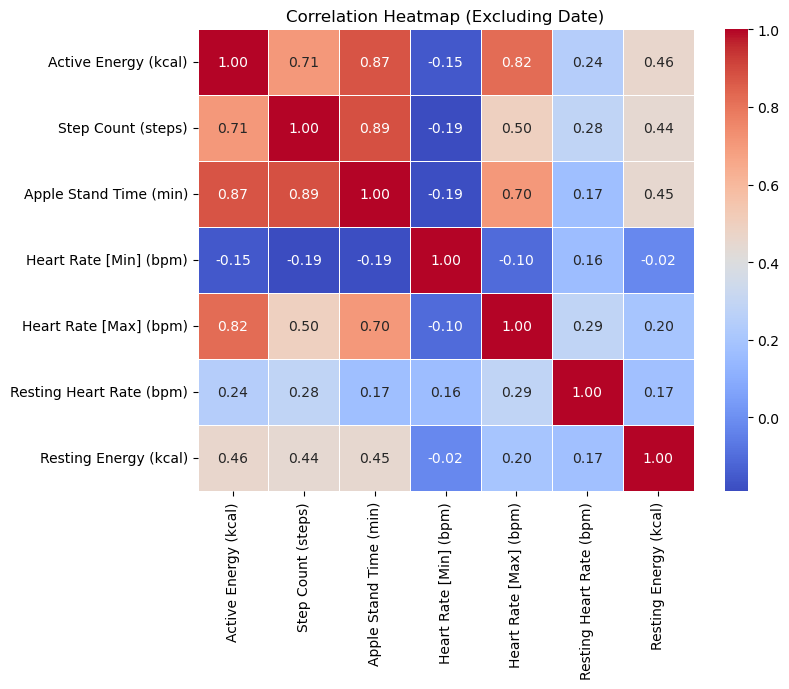

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Excluding Date)")
plt.show()

C:\Users\oba032\AppData\Local\Temp\ipykernel_13748\1203180095.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations, y=variables, palette=["red" if c < 0 else "blue" for c in correlations], orient='h')


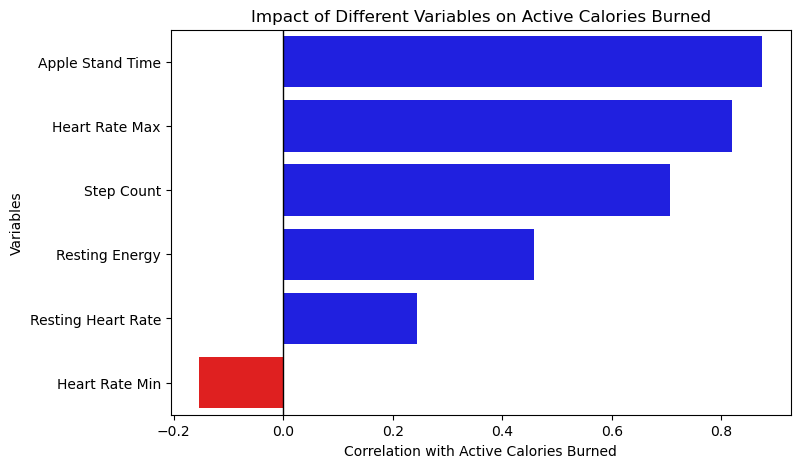

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ["Apple Stand Time", "Heart Rate Max", "Step Count", "Resting Energy", "Resting Heart Rate", "Heart Rate Min"]
correlations = [0.875, 0.819, 0.706, 0.457, 0.245, -0.154]

plt.figure(figsize=(8, 5))
sns.barplot(x=correlations, y=variables, palette=["red" if c < 0 else "blue" for c in correlations], orient='h')

plt.xlabel("Correlation with Active Calories Burned")
plt.ylabel("Variables")
plt.title("Impact of Different Variables on Active Calories Burned")
plt.axvline(x=0, color='black', linewidth=1)

plt.show()


In [50]:
grouped = df.groupby('Date').agg({
    'Active Energy (kcal)': 'sum',
    'Step Count (steps)': 'sum',
    'Apple Stand Time (min)': 'sum',
    'Heart Rate [Min] (bpm)': 'mean',
    'Heart Rate [Max] (bpm)': 'mean',
    'Resting Heart Rate (bpm)': 'mean',
    'Resting Energy (kcal)': 'mean',
    'Sleep Analysis [Asleep] (hr)': 'sum',
    'Sleep Analysis [Core] (hr)': 'sum',
    'Sleep Analysis [Deep] (hr)': 'sum',
    'Sleep Analysis [REM] (hr)': 'sum'
}).reset_index()

grouped["Total Sleep (hr)"] = (
    grouped["Sleep Analysis [Asleep] (hr)"] +
    grouped["Sleep Analysis [Core] (hr)"] +
    grouped["Sleep Analysis [Deep] (hr)"] +
    grouped["Sleep Analysis [REM] (hr)"]
)


In [51]:
grouped = grouped.drop(columns=['Sleep Analysis [Asleep] (hr)', 
                                'Sleep Analysis [Core] (hr)', 
                                'Sleep Analysis [Deep] (hr)', 
                                'Sleep Analysis [REM] (hr)'])


In [52]:
correlation_matrix = grouped.drop(columns=['Date']).corr()

active_energy_corr = correlation_matrix['Active Energy (kcal)'].sort_values(ascending=False)

print(active_energy_corr)


ValueError: could not convert string to float: '2,5833333333,2250,4750,45'

In [77]:
print(grouped.dtypes)


Date                        datetime64[ns]
Active Energy (kcal)               float64
Step Count (steps)                   int64
Apple Stand Time (min)             float64
Heart Rate [Min] (bpm)             float64
Heart Rate [Max] (bpm)             float64
Resting Heart Rate (bpm)           float64
Resting Energy (kcal)              float64
Total Sleep (hr)                    object
dtype: object


In [79]:
print(grouped["Total Sleep (hr)"].unique())


[0 '2,5833333333,2250,4750,45' '05,9916666670,9583333330,983333333'
 '04,8833333331,2583333331,716666667' '06,37511,383333333'
 '2,9083333332,6750,2666666670,475' '02,0750,40,625'
 '3,7333333335,1166666670,4833333332,266666667'
 '03,8583333330,1166666670,633333333' '03,60,3750,733333333'
 '2,3833333337,3916666670,5166666671,325' '05,6833333330,6751'
 '2,4166666673,4333333330,5083333330,941666667'
 '04,2666666670,8250,641666667' '040,4833333330,858333333'
 '03,90,8666666671,441666667' '1,14,0583333330,5251,891666667'
 '1,3833333333,4833333330,5416666670,8' '1,2916666674,7583333330,50,725'
 '02,7750,651,266666667' '1,1833333333,7750,8583333331'
 '04,6583333331,2416666671,4' '04,250,9333333331,3'
 '04,7833333331,2251,475' '02,750,5166666670,725'
 '1,4583333333,1083333331,41,183333333' '03,350,9251,55'
 '03,150,5666666671,35' '04,3833333330,6916666671,266666667'
 '05,1166666670,8083333331,716666667'
 '1,5166666674,4333333330,6833333331,825' '03,2250,8916666670,966666667'
 '5,791666667000' 

In [81]:
grouped["Total Sleep (hr)"] = (
    grouped["Total Sleep (hr)"]
    .astype(str)  # Ensure it's a string
    .str.replace(r'[^\d.]', '', regex=True)  # Remove all non-numeric characters except the decimal point
    .astype(float)  # Convert to float
)


In [83]:
print(grouped["Total Sleep (hr)"].dtype)


float64


In [85]:
correlation_matrix = grouped.drop(columns=['Date']).corr()
print(correlation_matrix['Active Energy (kcal)'].sort_values(ascending=False))


Active Energy (kcal)        1.000000
Apple Stand Time (min)      0.883024
Heart Rate [Max] (bpm)      0.831747
Step Count (steps)          0.722504
Resting Energy (kcal)       0.510592
Resting Heart Rate (bpm)    0.244918
Total Sleep (hr)           -0.006149
Heart Rate [Min] (bpm)     -0.237024
Name: Active Energy (kcal), dtype: float64


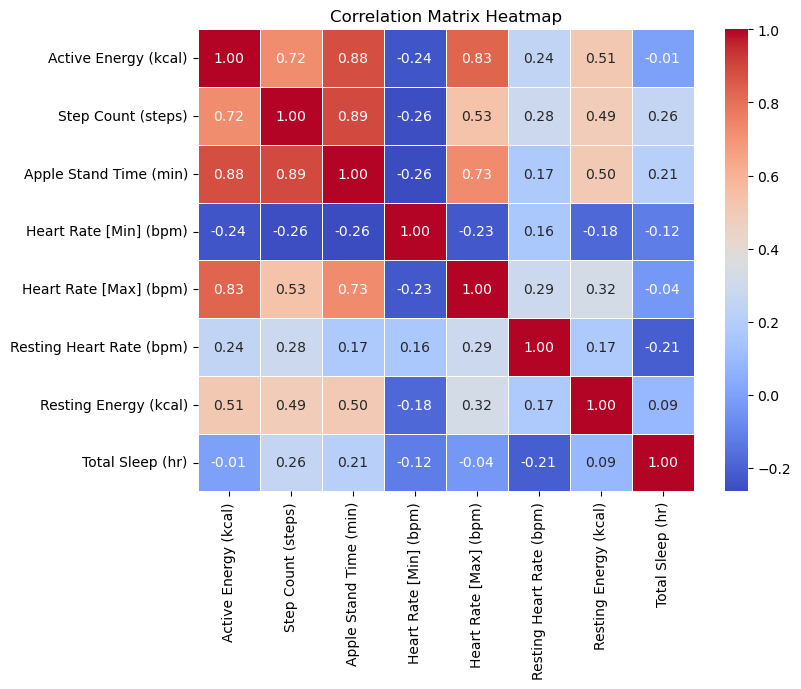

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = grouped.drop(columns=['Date']).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix Heatmap")
plt.show()


C:\Users\oba032\AppData\Local\Temp\ipykernel_13748\2946290262.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=active_energy_corr.values, y=active_energy_corr.index,


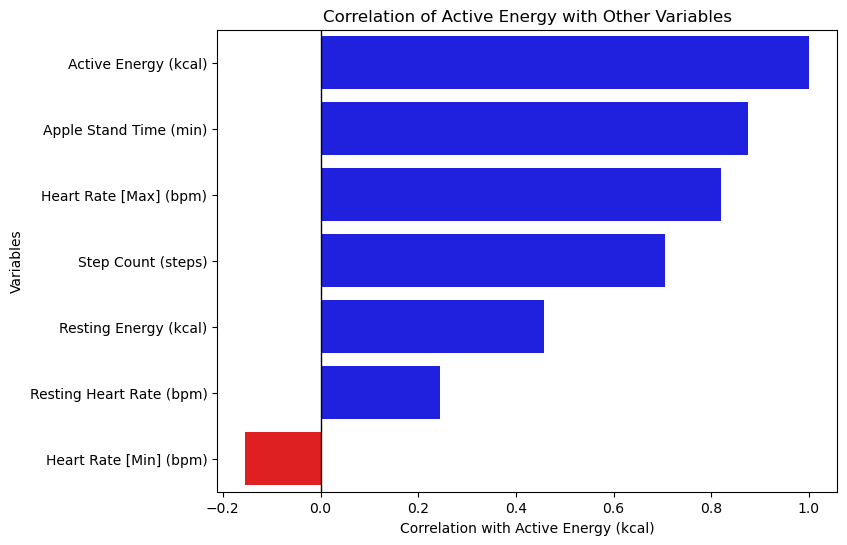

In [60]:
active_energy_corr = correlation_matrix['Active Energy (kcal)'].sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=active_energy_corr.values, y=active_energy_corr.index, 
            palette=["red" if c < 0 else "blue" for c in active_energy_corr.values], orient='h')

plt.xlabel("Correlation with Active Energy (kcal)")
plt.ylabel("Variables")
plt.title("Correlation of Active Energy with Other Variables")

plt.axvline(x=0, color='black', linewidth=1)

plt.show()


In [99]:
import scipy.stats as stats
import pandas as pd

df_numeric = grouped.drop(columns=['Date'])

correlation_matrix = pd.DataFrame(index=df_numeric.columns, columns=df_numeric.columns)
p_value_matrix = pd.DataFrame(index=df_numeric.columns, columns=df_numeric.columns)

for col1 in df_numeric.columns:
    for col2 in df_numeric.columns:
        if col1 == col2:
            correlation_matrix.loc[col1, col2] = 1.0
            p_value_matrix.loc[col1, col2] = 0.0
        else:
            r, p = stats.pearsonr(df_numeric[col1], df_numeric[col2])
            correlation_matrix.loc[col1, col2] = r
            p_value_matrix.loc[col1, col2] = p

correlation_matrix = correlation_matrix.astype(float)
p_value_matrix = p_value_matrix.astype(float)

print("Pearson Correlation Matrix:")
print(correlation_matrix)

print("\nP-Value Matrix:")
print(p_value_matrix)


ValueError: array must not contain infs or NaNs

In [64]:
import numpy as np

print("Missing values per column:\n", grouped.isna().sum())
print("\nInfinite values per column:\n", grouped.replace([np.inf, -np.inf], np.nan).isna().sum())


Missing values per column:
 Date                        0
Active Energy (kcal)        0
Step Count (steps)          0
Apple Stand Time (min)      0
Heart Rate [Min] (bpm)      0
Heart Rate [Max] (bpm)      0
Resting Heart Rate (bpm)    1
Resting Energy (kcal)       0
Total Sleep (hr)            0
dtype: int64

Infinite values per column:
 Date                        0
Active Energy (kcal)        0
Step Count (steps)          0
Apple Stand Time (min)      0
Heart Rate [Min] (bpm)      0
Heart Rate [Max] (bpm)      0
Resting Heart Rate (bpm)    1
Resting Energy (kcal)       0
Total Sleep (hr)            0
dtype: int64


In [101]:
grouped_cleaned = grouped.replace([np.inf, -np.inf], np.nan).dropna()


In [103]:
import scipy.stats as stats
import pandas as pd

df_numeric = grouped_cleaned.drop(columns=['Date'])

correlation_matrix = pd.DataFrame(index=df_numeric.columns, columns=df_numeric.columns)
p_value_matrix = pd.DataFrame(index=df_numeric.columns, columns=df_numeric.columns)
for col1 in df_numeric.columns:
    for col2 in df_numeric.columns:
        if col1 == col2:
            correlation_matrix.loc[col1, col2] = 1.0
            p_value_matrix.loc[col1, col2] = 0.0
        else:
            r, p = stats.pearsonr(df_numeric[col1], df_numeric[col2])
            correlation_matrix.loc[col1, col2] = r
            p_value_matrix.loc[col1, col2] = p
correlation_matrix = correlation_matrix.astype(float)
p_value_matrix = p_value_matrix.astype(float)


print("Pearson Correlation Matrix:")
print(correlation_matrix)
print("\nP-Value Matrix:")
print(p_value_matrix)


Pearson Correlation Matrix:
                          Active Energy (kcal)  Step Count (steps)  \
Active Energy (kcal)                  1.000000            0.705556   
Step Count (steps)                    0.705556            1.000000   
Apple Stand Time (min)                0.874623            0.885786   
Heart Rate [Min] (bpm)               -0.153984           -0.190730   
Heart Rate [Max] (bpm)                0.819125            0.496828   
Resting Heart Rate (bpm)              0.244918            0.284938   
Resting Energy (kcal)                 0.457293            0.443956   
Total Sleep (hr)                     -0.013191            0.259473   

                          Apple Stand Time (min)  Heart Rate [Min] (bpm)  \
Active Energy (kcal)                    0.874623               -0.153984   
Step Count (steps)                      0.885786               -0.190730   
Apple Stand Time (min)                  1.000000               -0.185510   
Heart Rate [Min] (bpm)               

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


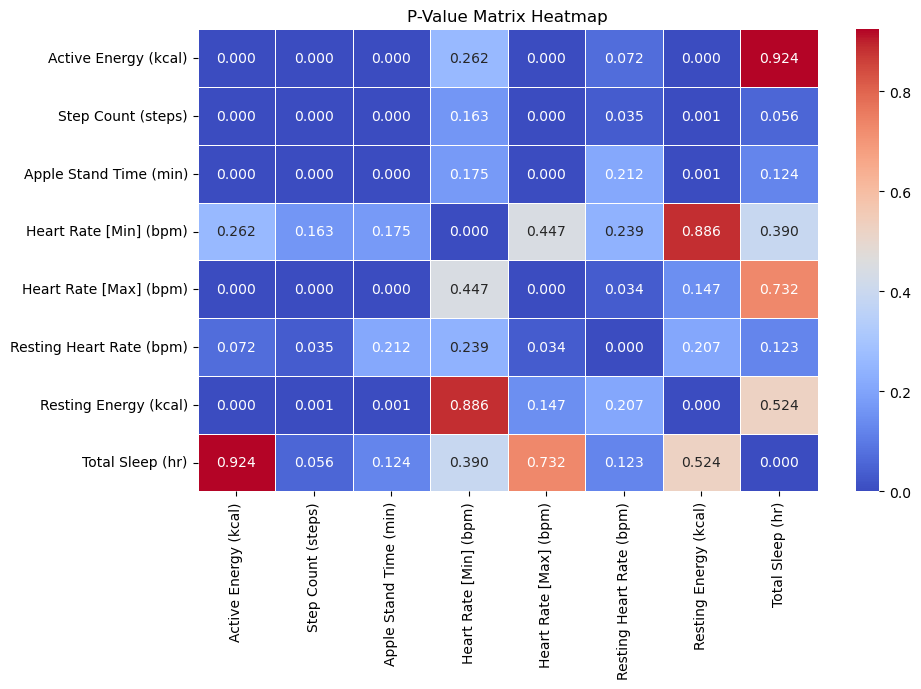

In [107]:
plt.figure(figsize=(10, 6))
sns.heatmap(p_value_matrix, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5, cbar=True)
plt.title("P-Value Matrix Heatmap")
plt.show()


In [109]:
significance_level = 0.05

summary_sentences = []

for col in df_numeric.columns:
    if col != "Active Energy (kcal)":
        r = correlation_matrix.loc["Active Energy (kcal)", col]
        p = p_value_matrix.loc["Active Energy (kcal)", col]

        direction = "positive" if r > 0 else "negative"
        if p < significance_level:
            sentence = f"The {direction} correlation between {col} and Active Energy (kcal) was significant (r = {r:.2f}, p = {p:.3f})."
        else:
            sentence = f"The {direction} correlation between {col} and Active Energy (kcal) was not statistically significant (r = {r:.2f}, p = {p:.3f})."

        summary_sentences.append((p, sentence))

summary_sentences.sort()
for _, sentence in summary_sentences:
    print(sentence)


The positive correlation between Apple Stand Time (min) and Active Energy (kcal) was significant (r = 0.87, p = 0.000).
The positive correlation between Heart Rate [Max] (bpm) and Active Energy (kcal) was significant (r = 0.82, p = 0.000).
The positive correlation between Step Count (steps) and Active Energy (kcal) was significant (r = 0.71, p = 0.000).
The positive correlation between Resting Energy (kcal) and Active Energy (kcal) was significant (r = 0.46, p = 0.000).
The positive correlation between Resting Heart Rate (bpm) and Active Energy (kcal) was not statistically significant (r = 0.24, p = 0.072).
The negative correlation between Heart Rate [Min] (bpm) and Active Energy (kcal) was not statistically significant (r = -0.15, p = 0.262).
The negative correlation between Total Sleep (hr) and Active Energy (kcal) was not statistically significant (r = -0.01, p = 0.924).
